<a href="https://colab.research.google.com/github/Faitz761/Tugas-Pengolahan-Citra-Digital/blob/main/PCD_minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

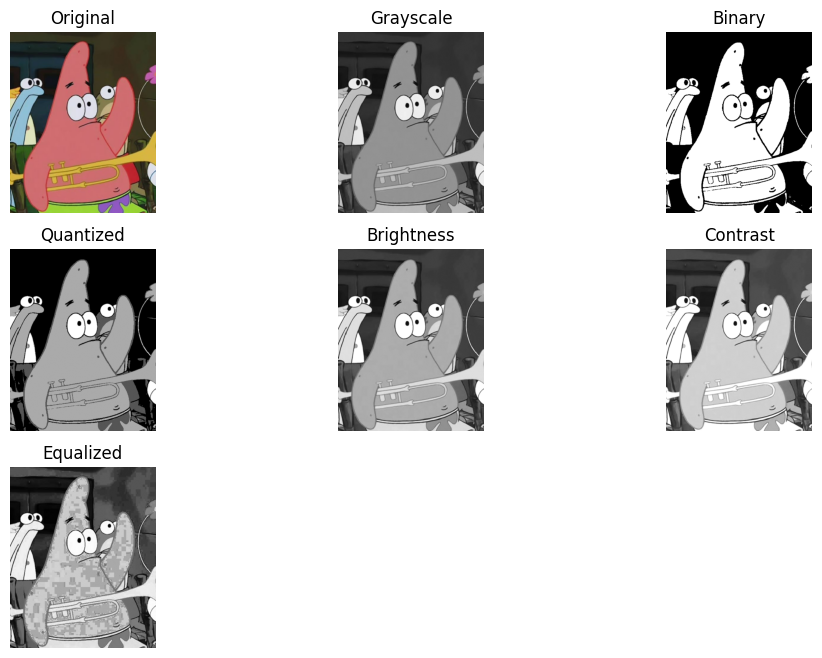

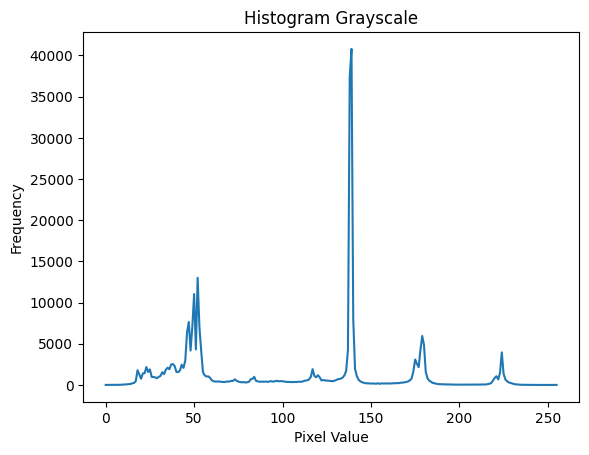

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("patrick.jpg")  # ganti dengan nama file kamu
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. RGB -> Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Grayscale -> Biner (thresholding)
_, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

# 3. Grayscale -> m-bit (quantization, contoh 2-bit = 4 level)
m = 2
levels = 2 ** m
quantized = np.floor(gray / (256 / levels)) * (256 / levels)
quantized = quantized.astype(np.uint8)

# 4. Brightness adjustment
brightness = 50
bright_img = cv2.convertScaleAbs(gray, alpha=1, beta=brightness)

# 5. Contrast adjustment
alpha = 1.5  # contrast factor
contrast_img = cv2.convertScaleAbs(gray, alpha=alpha, beta=0)

# 6. Histogram grayscale
hist = cv2.calcHist([gray], [0], None, [256], [0,256])

# 7. Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Display hasil
titles = ['Original', 'Grayscale', 'Binary', 'Quantized',
          'Brightness', 'Contrast', 'Equalized']

images = [img_rgb, gray, binary, quantized,
          bright_img, contrast_img, equalized]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

# tampilkan histogram
plt.figure()
plt.plot(hist)
plt.title("Histogram Grayscale")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()